In [75]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [76]:
from langchain.agents import create_agent
from typing_extensions import TypedDict,Annotated

class BlogState(TypedDict):

    youtube_url: str

    raw_metadata: str

    cleaned_content: str

    summary: str

    blog_title: str

    blog_content: str
    
from pydantic import BaseModel

class BlogPost(BaseModel):
    title: str
    content: str

In [77]:
from langchain.chat_models import init_chat_model
model=init_chat_model("groq:openai/gpt-oss-120b")

In [78]:
from yt_dlp import YoutubeDL
from youtube_transcript_api import YouTubeTranscriptApi
from urllib.parse import urlparse, parse_qs

def extract_youtube_data(state: BlogState):
    """
    Takes YouTube URL and returns:
    - title
    - description
    - transcript
    """

    # -------- Extract Metadata --------

    with YoutubeDL({}) as ydl:
        info = ydl.extract_info(state['youtube_url'], download=False)

    title = info.get("title", "")
    description = info.get("description", "")

    # -------- Extract Video ID --------


    parsed_url = urlparse(state['youtube_url'])

    if parsed_url.hostname in ["www.youtube.com", "youtube.com"]:
        video_id = parse_qs(parsed_url.query).get("v", [None])[0]

    if parsed_url.hostname == "youtu.be":
        video_id = parsed_url.path[1:]

    if not video_id:
        return "Invalid YouTube URL"

    # -------- Get Transcript --------

    try:
        api = YouTubeTranscriptApi()

        transcript = api.fetch(video_id)

        transcript_text = " ".join([x.text for x in transcript])

    except Exception as e:

        transcript_text = f"Transcript not available: {str(e)}"

    # -------- Final Combined Output --------

    final_text = f"""
        TITLE:
        {title}

        DESCRIPTION:
        {description}

        TRANSCRIPT:
        {transcript_text}
        """

    return {
        "raw_metadata": final_text
    }

In [79]:
def clean_metadata(state: BlogState):

    raw_data = state["raw_metadata"]

    response = model.invoke(f"""
    Clean this YouTube metadata and transcript.
    
    Focus on:
    - main topic
    - important concepts
    - remove noise
    - prioritize title and transcript
    
    DATA:
    {raw_data}
    """)

    return {
        "cleaned_content": response.content
    }
    

In [80]:
def summarize_content(state: BlogState):

    content = state["cleaned_content"]

    response = model.invoke(f"""
    Summarize this content into key points.

    {content}
    """)

    return {
        "summary": response.content
    }

In [81]:
def generate_blog_title(state: BlogState):

    summary = state["summary"]

    response = model.invoke(f"""
    Generate SEO friendly blog title.

    {summary}
    """)

    return {
        "blog_title": response.content
    }

In [82]:
def generate_blog(state: BlogState):

    title = state["blog_title"]

    summary = state["summary"]

    response = model.invoke(f"""
    Write detailed professional blog.

    TITLE:
    {title}

    CONTENT:
    {summary}
    """)

    return {
        "blog_content": response.content
    }

In [83]:
def generate_blog_post(state: BlogState):

    summary = state["summary"]

    response = structured_model.invoke(f"""
    
    Create:
    
    1. Short engaging blog title
    2. Clean blog post
    
    Rules:
    - concise
    - readable
    - not overly long
    - avoid excessive headings
    - human friendly
    - blog should feel like social/article post
    
    CONTENT:
    {summary}
    """)

    return {
        "blog_title": response.title,
        "blog_content": response.content
    }

In [84]:
from langgraph.graph import START, END,StateGraph

builder = StateGraph(BlogState)

builder.add_node("extract", extract_youtube_data)
builder.add_node("clean", clean_metadata)
builder.add_node("summarize", summarize_content)
builder.add_node("generate_post", generate_blog_post)

builder.add_edge(START, "extract")
builder.add_edge("extract", "clean")
builder.add_edge("clean", "summarize")
builder.add_edge("summarize", "generate_post")
builder.add_edge("generate_post", END)

graph = builder.compile()

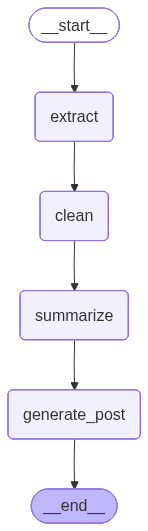

In [85]:
graph

In [89]:
result = graph.invoke({
    "youtube_url": "https://youtu.be/7nGN11DW-b0?si=b75ldsljj3hTvLPY"
})
print(result["blog_title"])
print(result["blog_content"])

[youtube] Extracting URL: https://youtu.be/7nGN11DW-b0?si=b75ldsljj3hTvLPY
[youtube] 7nGN11DW-b0: Downloading webpage


[youtube] 7nGN11DW-b0: Downloading android vr player API JSON


BadRequestError: Error code: 400 - {'error': {'message': 'Tool choice is required, but model did not call a tool', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '**Title:**  \n*“UFO Files Unveiled: What the Pentagon’s New Docs Really Say About Aliens”*  \n\n**Blog Post:**  \n\nThe Pentagon’s May\u202f2026 drop of 162 previously classified UFO files has set the internet buzzing. Among the trove are 28 videos and 14 images that show objects darting, splitting, and glowing in ways that look straight out of a sci‑fi flick. But what do the documents actually tell us?\n\nFirst, the recent sightings are striking. In 2023, federal agents recorded a massive orange orb that shed smaller red spheres, and in 2025 a helicopter chase captured an object covering roughly 20\u202fmiles in a few seconds—again shedding “mini‑orbs.” These clips are dramatic, but they’re just a slice of a much larger picture.\n\nThe history of UFO chatter stretches back to 1947, when Kenn